# GRÁFICA DE DISTRIBUCIÓN DE ENERGÍA POR CONTINENTE

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create a continent mapping
continent_map = {
    'Africa': ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'Cote d\'Ivoire', 'Democratic Republic of the Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'],
    'Asia': ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Brunei Darussalam', 'Cambodia', 'China', 'Cyprus', 'Georgia', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia','Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'North Korea', 'Oman', 'Pakistan', 'Palestine', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Syria', 'Taiwan', 'Tajikistan', 'Thailand', 'Timor-Leste', 'Turkey', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen'],
    'Europe': ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom', 'Vatican City'],
    'North America': ['Canada', 'Greenland', 'Mexico', 'United States'],
    'Oceania': ['Australia', 'Fiji', 'New Zealand', 'Papua New Guinea'],
    'South America': ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela']
}


In [11]:
dataset = pd.read_csv ("World Energy Consumption.csv")

In [12]:
col_electricity = ['low_carbon_electricity',
            'nuclear_electricity',
            'oil_electricity',
            'other_renewable_electricity',
            'other_renewable_exc_biofuel_electricity',
            'solar_electricity',
            'wind_electricity',
            'fossil_electricity',
            'gas_electricity',
            'hydro_electricity',
            'biofuel_electricity',
            'coal_electricity']
col_cons =['biofuel_consumption',
           'coal_consumption',
           'fossil_fuel_consumption',
           'gas_consumption',
           'hydro_consumption',
           'low_carbon_consumption',
           'nuclear_consumption',
           'oil_consumption',
           'solar_consumption']

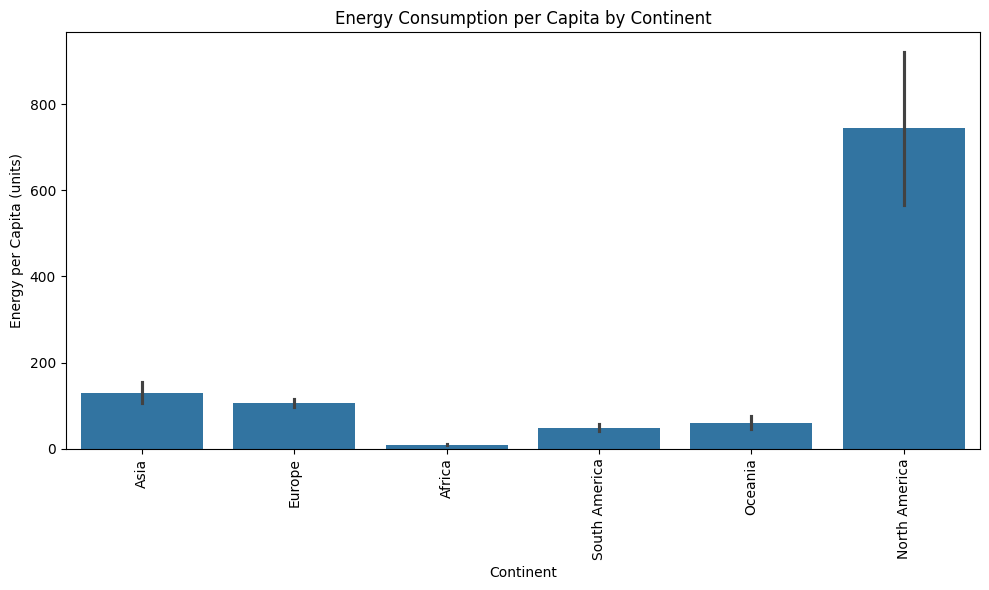

In [13]:
dataset = dataset.groupby(['year','country'])[col_electricity].sum().sum(axis=1).to_frame('electricity_generation').reset_index("country")

# Filter out rows with missing 'energy_per_capita' values
dataset_filtered = dataset[dataset['electricity_generation'].notna()]

# Add a 'continent' column to the dataset
dataset_filtered['continent'] = dataset_filtered['country'].map(lambda x: next((k for k, v in continent_map.items() if x in v), None))
dataset_filtered = dataset_filtered[dataset_filtered['continent'].notna()]

# Plot energy consumption per capita across continents
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=dataset_filtered, x='continent', y='electricity_generation', ax=ax)
ax.set_title('Energy Consumption per Capita by Continent')
ax.set_xlabel('Continent')
ax.set_ylabel('Energy per Capita (units)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



# FILTROS PARA TOMAR DESDE 1986

In [14]:
dataset_continentes = dataset_filtered.groupby(["year","continent"])["electricity_generation"].sum().to_frame('electricity_generation').reset_index("continent")
dataset_continentes_filt = dataset_continentes[dataset_continentes["electricity_generation"]>0]
dataset_continentes_filt = dataset_continentes_filt[dataset_continentes_filt.index>=1986]

## DATOS EUROPA

In [15]:
dataset_europa = dataset_continentes_filt[dataset_continentes_filt["continent"]=="Europe"]
dataset_europa.drop(columns=["continent"])
dataset_europa = dataset_europa.reset_index()

## DATOS NORTEAMERICA

In [16]:
dataset_norteamerica = dataset_continentes_filt[dataset_continentes_filt["continent"]=="North America"]
dataset_norteamerica = dataset_norteamerica.reset_index()
dataset_norteamerica =dataset_norteamerica.drop(columns=["continent"])


# MODELO PROPHET

In [17]:
import pandas as pd
import numpy as np
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

def europa_norteamerica (dato):
    # Prepare data for Prophet
    prophet_data = dato.copy()
    prophet_data['ds'] = pd.to_datetime(prophet_data['year'], format='%Y')
    prophet_data['y'] = prophet_data['electricity_generation']
    
    # Define parameter grid for optimization
    param_grid = {
        'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
        'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
        'seasonality_mode': ['additive', 'multiplicative']
    }
    
    # Generate all combinations of parameters
    all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
    rmses = []
    
    # Use 80% of data for training
    train_size = int(len(prophet_data) * 0.7)
    train_data = prophet_data[:train_size]
    test_data = prophet_data[train_size:]
    
    # Evaluate all parameters
    print("Finding best parameters...")
    best_rmse = float('inf')
    best_params = None

    for params in all_params:
        # Create and fit model
        model = Prophet(
            yearly_seasonality=True,
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            seasonality_mode=params['seasonality_mode']
        )
        
        model.fit(train_data)
        
        # Make predictions for test period
        future = model.make_future_dataframe(periods=len(test_data), freq='Y')
        forecast = model.predict(future)
        
        # Calculate error
        test_predictions = forecast.iloc[-len(test_data):]
        rmse = np.sqrt(mean_squared_error(test_data['y'], test_predictions['yhat']))
        rmses.append(rmse)
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    print("\nBest parameters:")
    for param, value in best_params.items():
        print(f"{param}: {value}")
    print(f"Best RMSE: {best_rmse:.2f}")
    
    # Fit final model with best parameters
    final_model = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=best_params['seasonality_mode']
    )
    final_model.fit(prophet_data)
    
    # Make future predictions
    future = final_model.make_future_dataframe(periods=5, freq='Y')
    forecast = final_model.predict(future)
    
    # Create visualization plots
    plt.figure(figsize=(20, 12))

    """# Plot 1: Original data with forecast
    plt.subplot(2, 2, 1)
    fig1 = final_model.plot(forecast)
    plt.title('Prophet Forecast with Best Parameters')
    plt.xlabel('Year')
    plt.ylabel('Generation')
    
    # Plot 2: Components (in separate figure)
    fig2 = final_model.plot_components(forecast)
    plt.close(fig2)  # Close the components figure as we'll show it separately
    
    # Plot 3: Changepoints
    plt.subplot(2, 2, 3)
    final_model.plot(forecast)
    deltas = final_model.params['delta'][0]
    for cp in final_model.changepoints:
        plt.axvline(cp, color='r', alpha=0.2)
    plt.title('Changepoints')
    
    # Plot 4: Validation
    plt.subplot(2, 2, 4)
    plt.plot(test_data['ds'], test_data['y'], 'r.', label='Actual')
    plt.plot(test_predictions['ds'], test_predictions['yhat'], 'b-', label='Predicted')
    plt.fill_between(test_predictions['ds'], 
                     test_predictions['yhat_lower'], 
                     test_predictions['yhat_upper'], 
                     color='b', alpha=0.2)
    plt.title('Model Validation on Test Set')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Show components plot separately
    plt.figure(figsize=(12, 8))
    final_model.plot_components(forecast)
    plt.show()
    
    # Print forecast for next 5 years
    future_forecast = forecast[forecast['ds'].dt.year > 2022][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    print("\nForecast for next 5 years:")
    print(future_forecast.round(2))"""
        
    # Print additional metrics for test set
    mae = mean_absolute_error(test_data['y'], test_predictions['yhat'])
    mape = np.mean(np.abs((test_data['y'] - test_predictions['yhat']) / test_data['y'])) * 100
    
    print("\nTest Set Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {best_rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    
    plt.figure(figsize=(10, 6))
    
    # Datos reales
    plt.plot(prophet_data['ds'], prophet_data['y'], 'r-', label="Datos reales")
    
    # Predicción
    plt.plot(forecast['ds'], forecast['yhat'], 'b-', label="Predicción")
    
    # Intervalo de confianza
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                     color='blue', alpha=0.2, label="Intervalo de confianza")
    
    # Etiquetas y título
    plt.xlabel("Año")
    plt.ylabel("Generación de electricidad")
    plt.title("Predicción de Generación de Electricidad con Prophet")
    plt.legend()
    plt.grid()
    
    plt.show()

# DESCOMENTAR Y CORRER EUROPA O NORTEAMERICA

In [19]:
#europa_norteamerica(dataset_europa)
#europa_norteamerica(dataset_norteamerica)